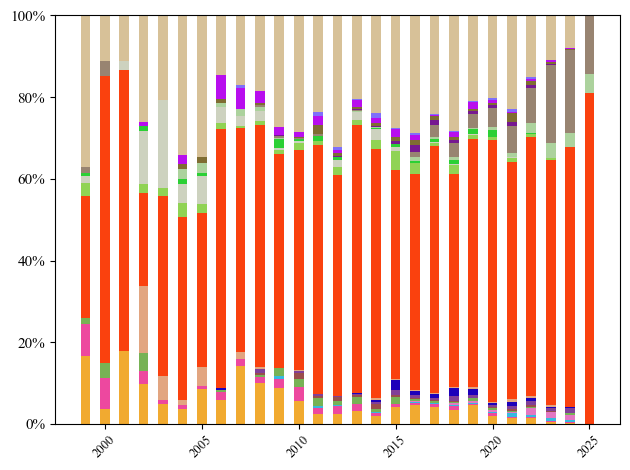

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib import ticker
import matplotlib as mpl

mpl.rcParams["pdf.fonttype"] = 42   # 可编辑文本模式
mpl.rcParams["ps.fonttype"] = 42    # 兼容PostScript
mpl.rcParams["font.family"] = "Times New Roman"  # 指定具体字体
# 读取数据
df_genome_year = pd.read_csv(r"D:\A.baumannii\data\ST_year_Final.csv",  header=0)


def random_color(number):
    color = []
    intnum = [str(x) for x in np.arange(10)]
    alphabet = [chr(x) for x in (np.arange(6) + ord('A'))]
    colorArr = np.hstack((intnum, alphabet))
    for j in range(number):
        color_single = '#'
        for i in range(6):
            index = np.random.randint(len(colorArr))
            color_single += colorArr[index]
        color.append(color_single)
    return color

ST_list = df_genome_year["ST"].to_list()
ST_list = list(set(ST_list))

color_ST_dict = {
    'ST1': '#F1AA30', 'ST10': '#ED489F', 'ST108': '#35BADF', 'ST1091': '#E377C2',
    'ST15': '#77B255', 'others': '#D7C198', 'ST16': '#813F98', 'unknown': "#CBC6C7",
    'ST164': '#1C00BA', 'ST19': '#E2A580', 'ST3': '#CDD2BF', 'ST25': '#90D354',
    'ST2': "#FA410E", 'ST40': '#2BD035', 'ST406': '#ACD29D', 'ST499': '#988471',
    'ST636': '#761891', 'ST156': '#9A4D4C', 'ST78': '#7F6D32', 'ST79': '#B80EEE',
    'ST85': '#7F6FFB'
}

fig = plt.figure()
ax = fig.add_subplot(111)
df_genome_year.set_index(["ST"], inplace=True)
df_genome_mcr = df_genome_year / df_genome_year.sum(axis=0)
bottom_y = np.zeros(len(df_genome_mcr.columns))

for y, color_index in zip(df_genome_mcr.values, df_genome_mcr.index):
    ax.bar(df_genome_mcr.columns, y, width=0.5, bottom=bottom_y, color=color_ST_dict[color_index], label=color_index)
    bottom_y += y

ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax.set_xticks([1, 6, 11, 16, 21, 26])
ax.set_xticklabels(['2000', '2005', '2010', '2015', '2020', '2025'])


plt.yticks(fontname='Times New Roman', size=11)
plt.xticks(fontname='Times New Roman',  size=9,rotation=45)
plt.tight_layout()


plt.savefig("st_year.png", dpi = 600)


plt.show()
